In [1]:
!pip install mlxtend

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
     ------- ---

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 100)

In [2]:
df_clean = pd.read_excel("df_clean.xlsx")

In [3]:
print("df_clean shape:", df_clean.shape)
print("df_clean description:", df_clean.describe())

df_clean shape: (397884, 15)
df_clean description:            InvoiceNo       Quantity                    InvoiceDate  \
count  397884.000000  397884.000000                         397884   
mean   560616.934451      12.988238  2011-07-10 23:41:23.511023360   
min    536365.000000       1.000000            2010-12-01 08:26:00   
25%    549234.000000       2.000000            2011-04-07 11:12:00   
50%    561893.000000       6.000000            2011-07-31 14:39:00   
75%    572090.000000      12.000000            2011-10-20 14:33:00   
max    581587.000000   80995.000000            2011-12-09 12:50:00   
std     13106.117773     179.331775                            NaN   

           UnitPrice     CustomerID                           Date  \
count  397884.000000  397884.000000                         397884   
mean        3.116488   15294.423453  2011-07-10 10:27:17.518472704   
min         0.001000   12346.000000            2010-12-01 00:00:00   
25%         1.250000   13969.000000   

In [4]:
df_clean.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Date           datetime64[ns]
YearMonth      datetime64[ns]
Week                    int64
DayOfWeek               int64
IsWeekend               int64
Hour                    int64
Revenue               float64
dtype: object

In [5]:
df_clean["StockCode"] = df_clean["StockCode"].astype(str).str.strip()

In [6]:
df_clean.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
Date           datetime64[ns]
YearMonth      datetime64[ns]
Week                    int64
DayOfWeek               int64
IsWeekend               int64
Hour                    int64
Revenue               float64
dtype: object

# Associate Rules Analysis

## Build basket(for running Apriori and FP-growth) and df_goods for latter searching

In [7]:
df_mba=df_clean.copy()

In [8]:
# 同一订单中同一商品可能出现多行，先合并数量
df_associate = (
    df_mba.groupby(["InvoiceNo", "StockCode"], as_index=False)
    .agg({
        "Quantity": "sum"
    })
)

# 只保留购买数量 > 0 的商品记录
df_associate = df_associate[df_associate["Quantity"] > 0].copy()

print("df_associate shape:", df_associate.shape)
df_associate.head(10)

df_associate shape: (387841, 3)


,InvoiceNo,StockCode,Quantity
0,536365,21730,6
1,536365,22752,2
2,536365,71053,6
3,536365,84029E,6
4,536365,84029G,6
5,536365,84406B,8
6,536365,85123A,6
7,536366,22632,6
8,536366,22633,6
9,536367,21754,3


In [9]:
basket = (
    df_associate.assign(value=1)
    .pivot_table(
        index="InvoiceNo",
        columns="StockCode",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

# 转成布尔/整型都可以
basket = basket.astype(bool)

print("basket shape:", basket.shape)
basket.head()

basket shape: (18532, 3665)


StockCode,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,15030,15034,15036,15039,15044A,15044B,15044C,15044D,15056BL,15056N,15056P,15058A,15058B,15058C,15060B,16008,16010,16011,16012,16014,16015,16016,16020C,16033,16043,16045,16046,16048,16049,16052,16054,16151A,16156L,16156S,16161G,16161M,16161P,16161U,16162L,16162M,...,90202B,90202C,90202D,90204,90205A,90205C,90206A,90206C,90208,90209A,90209B,90209C,90210A,90210B,90210C,90210D,90211A,90211B,90212B,90212C,90214A,90214B,90214C,90214D,90214E,90214F,90214G,90214H,90214I,90214J,90214K,90214L,90214M,90214N,90214O,90214P,90214R,90214S,90214T,90214U,90214V,90214W,90214Y,90214Z,BANK CHARGES,C2,DOT,M,PADS,POST
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
# Build df_goods for searching 统计每个 StockCode - Description 的出现次数
goods_count = (
    df_mba.groupby(["StockCode", "Description"])
    .size()
    .reset_index(name="cnt")
)

# 对每个 StockCode 取出现次数最多的 Description
df_goods = (
    goods_count.sort_values(["StockCode", "cnt"], ascending=[True, False])
    .drop_duplicates(subset=["StockCode"])
    [["StockCode", "Description"]]
    .reset_index(drop=True)
)

print("df_goods shape:", df_goods.shape)
df_goods.head(10)

df_goods shape: (3665, 2)


,StockCode,Description
0,10002,INFLATABLE POLITICAL GLOBE
1,10080,GROOVY CACTUS INFLATABLE
2,10120,DOGGY RUBBER
3,10123C,HEARTS WRAPPING TAPE
4,10124A,SPOTS ON RED BOOKCOVER TAPE
5,10124G,ARMY CAMO BOOKCOVER TAPE
6,10125,MINI FUNKY DESIGN TAPES
7,10133,COLOURING PENCILS BROWN TUBE
8,10135,COLOURING PENCILS BROWN TUBE
9,11001,ASSTD DESIGN RACING CAR PEN


In [11]:
# build goods mapping dictionary
goods_map = dict(zip(df_goods["StockCode"], df_goods["Description"]))

## Apriori

In [44]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 100)

# =========================================================
# 0. 参数设置（适合 basket shape: (18532, 3665)）
# =========================================================
APR_MIN_SUPPORT = 0.01     # Apriori建议先从1%开始
APR_MAX_LEN = 3            # 先限制到2项集，速度更稳

FP_MIN_SUPPORT = 0.01      # FP-Growth可先与Apriori保持一致
FP_MAX_LEN = 3             # FP-Growth可以放宽一点

RULE_METRIC = "confidence"
RULE_MIN_THRESHOLD = 0.30  # 先保留置信度>=30%的规则

FINAL_MIN_SUPPORT = 0.015   # 最终展示规则时可再筛一次
FINAL_MIN_CONFIDENCE = 0.5
FINAL_MIN_LIFT = 3.00


# =========================================================
#  辅助函数：把频繁项集/规则中的编码映射回商品名
# =========================================================
def format_itemset_codes(x):
    return ", ".join(sorted(list(x)))

def format_itemset_desc(x):
    return " | ".join([goods_map.get(code, code) for code in sorted(list(x))])

# =========================================================
#  Apriori 算法
# =========================================================
print("开始运行 Apriori ...")

frequent_itemsets_ap = apriori(
    basket,
    min_support=APR_MIN_SUPPORT,
    use_colnames=True,
    max_len=APR_MAX_LEN,
    low_memory=True
)

frequent_itemsets_ap["itemset_len"] = frequent_itemsets_ap["itemsets"].apply(len)
frequent_itemsets_ap["itemset_codes"] = frequent_itemsets_ap["itemsets"].apply(format_itemset_codes)
frequent_itemsets_ap["itemset_desc"] = frequent_itemsets_ap["itemsets"].apply(format_itemset_desc)

frequent_itemsets_ap = frequent_itemsets_ap.sort_values(
    ["support", "itemset_len"],
    ascending=[False, True]
).reset_index(drop=True)

print("Apriori 频繁项集数量：", frequent_itemsets_ap.shape[0])
display(frequent_itemsets_ap.head(20))

开始运行 Apriori ...
Apriori 频繁项集数量： 1029


,support,itemsets,itemset_len,itemset_codes,itemset_desc
0,0.106734,(85123A),1,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,0.091895,(22423),1,22423,REGENCY CAKESTAND 3 TIER
2,0.086337,(85099B),1,85099B,JUMBO BAG RED RETROSPOT
3,0.074412,(47566),1,47566,PARTY BUNTING
4,0.074196,(84879),1,84879,ASSORTED COLOUR BIRD ORNAMENT
5,0.069555,(20725),1,20725,LUNCH BAG RED RETROSPOT
6,0.061839,(22720),1,22720,SET OF 3 CAKE TINS PANTRY DESIGN
7,0.059303,(POST),1,POST,POSTAGE
8,0.058278,(23203),1,23203,JUMBO BAG VINTAGE DOILY
9,0.056767,(20727),1,20727,LUNCH BAG BLACK SKULL.


In [45]:
print("开始生成 Apriori 关联规则 ...")

rules_ap = association_rules(
    frequent_itemsets_ap[["support", "itemsets"]],
    metric=RULE_METRIC,
    min_threshold=RULE_MIN_THRESHOLD
)

rules_ap["antecedent_len"] = rules_ap["antecedents"].apply(len)
rules_ap["consequent_len"] = rules_ap["consequents"].apply(len)

rules_ap["antecedents_codes"] = rules_ap["antecedents"].apply(format_itemset_codes)
rules_ap["consequents_codes"] = rules_ap["consequents"].apply(format_itemset_codes)

rules_ap["antecedents_desc"] = rules_ap["antecedents"].apply(format_itemset_desc)
rules_ap["consequents_desc"] = rules_ap["consequents"].apply(format_itemset_desc)

#Limit the length of the antecedent
rules_ap = rules_ap[rules_ap["antecedent_len"] <= 2]

# Optimize the mirror image rules A-->B AND B-->A
rules_ap["pair"] = rules_ap.apply(
    lambda x: tuple(sorted(list(x["antecedents"]) + list(x["consequents"]))),
    axis=1
)

rules_ap = rules_ap.drop_duplicates(subset=["pair"])

rules_ap = rules_ap.sort_values(
    ["support", "confidence"],
    ascending=[False, False]
).reset_index(drop=True)


print("Apriori 关联规则数量：", rules_ap.shape[0])
display(rules_ap.head(20))

开始生成 Apriori 关联规则 ...
Apriori 关联规则数量： 346


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len,antecedents_codes,consequents_codes,antecedents_desc,consequents_desc,pair
0,(85099B),(22386),0.086337,0.047000,0.029463,0.341250,7.260672,1.0,0.025405,1.446680,0.943753,0.283636,0.308762,0.484058,1,1,85099B,22386,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,"(22386, 85099B)"
1,(22697),(22699),0.037287,0.042251,0.029193,0.782923,18.530185,1.0,0.027617,4.412029,0.982675,0.579850,0.773347,0.736928,1,1,22697,22699,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,"(22697, 22699)"
2,(22726),(22727),0.042575,0.047324,0.028599,0.671736,14.194548,1.0,0.026584,2.902169,0.970886,0.466549,0.655430,0.638035,1,1,22726,22727,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,"(22726, 22727)"
3,(22384),(20725),0.050237,0.069555,0.028221,0.561762,8.076466,1.0,0.024727,2.123147,0.922529,0.308191,0.529001,0.483751,1,1,22384,20725,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,"(20725, 22384)"
4,(22383),(20725),0.056281,0.069555,0.028006,0.497603,7.154057,1.0,0.024091,1.852011,0.911520,0.286266,0.460046,0.450120,1,1,22383,20725,LUNCH BAG SUKI DESIGN,LUNCH BAG RED RETROSPOT,"(20725, 22383)"
5,(20727),(20725),0.056767,0.069555,0.027898,0.491445,7.065521,1.0,0.023949,1.829585,0.910133,0.283443,0.453428,0.446265,1,1,20727,20725,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,"(20725, 20727)"
6,(82494L),(82482),0.043762,0.047270,0.025254,0.577065,12.207962,1.0,0.023185,2.252666,0.960102,0.383921,0.556082,0.555656,1,1,82494L,82482,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,"(82482, 82494L)"
7,(23203),(85099B),0.058278,0.086337,0.025254,0.433333,5.019083,1.0,0.020222,1.612346,0.850315,0.211573,0.379786,0.362917,1,1,23203,85099B,JUMBO BAG VINTAGE DOILY,JUMBO BAG RED RETROSPOT,"(23203, 85099B)"
8,(20725),(22382),0.069555,0.053313,0.025200,0.362296,6.795624,1.0,0.021491,1.484525,0.916601,0.258011,0.326384,0.417484,1,1,20725,22382,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,"(20725, 22382)"
9,(22383),(20727),0.056281,0.056767,0.025092,0.445829,7.853716,1.0,0.021897,1.702063,0.924716,0.285276,0.412478,0.443922,1,1,22383,20727,LUNCH BAG SUKI DESIGN,LUNCH BAG BLACK SKULL.,"(20727, 22383)"


In [46]:
# 频繁项集结果表
ap_itemsets_result = frequent_itemsets_ap[
    ["support", "itemset_len", "itemset_codes", "itemset_desc"]
].copy()

print("Apriori 频繁项集（展示前20条）")
display(ap_itemsets_result.head(20))

# 关联规则结果表
ap_rules_result = rules_ap[
    [
        "antecedents_codes", "antecedents_desc",
        "consequents_codes", "consequents_desc",
        "support", "confidence", "lift", "leverage", "conviction"
    ]
].copy()

print("Apriori 全部关联规则（展示前20条）")
display(ap_rules_result.head(20))

# 进一步筛选更有意义的规则
ap_rules_filtered = ap_rules_result[
    (ap_rules_result["support"] >= FINAL_MIN_SUPPORT) &
    (ap_rules_result["confidence"] >= FINAL_MIN_CONFIDENCE) &
    (ap_rules_result["lift"] > FINAL_MIN_LIFT)
].sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Apriori 筛选后的关联规则（展示前20条）")
display(ap_rules_filtered.head(20))
print("Apriori 筛选后规则数量：", ap_rules_filtered.shape[0])

Apriori 频繁项集（展示前20条）


,support,itemset_len,itemset_codes,itemset_desc
0,0.106734,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,0.091895,1,22423,REGENCY CAKESTAND 3 TIER
2,0.086337,1,85099B,JUMBO BAG RED RETROSPOT
3,0.074412,1,47566,PARTY BUNTING
4,0.074196,1,84879,ASSORTED COLOUR BIRD ORNAMENT
5,0.069555,1,20725,LUNCH BAG RED RETROSPOT
6,0.061839,1,22720,SET OF 3 CAKE TINS PANTRY DESIGN
7,0.059303,1,POST,POSTAGE
8,0.058278,1,23203,JUMBO BAG VINTAGE DOILY
9,0.056767,1,20727,LUNCH BAG BLACK SKULL.


Apriori 全部关联规则（展示前20条）


,antecedents_codes,antecedents_desc,consequents_codes,consequents_desc,support,confidence,lift,leverage,conviction
0,85099B,JUMBO BAG RED RETROSPOT,22386,JUMBO BAG PINK POLKADOT,0.029463,0.341250,7.260672,0.025405,1.446680
1,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.029193,0.782923,18.530185,0.027617,4.412029
2,22726,ALARM CLOCK BAKELIKE GREEN,22727,ALARM CLOCK BAKELIKE RED,0.028599,0.671736,14.194548,0.026584,2.902169
3,22384,LUNCH BAG PINK POLKADOT,20725,LUNCH BAG RED RETROSPOT,0.028221,0.561762,8.076466,0.024727,2.123147
4,22383,LUNCH BAG SUKI DESIGN,20725,LUNCH BAG RED RETROSPOT,0.028006,0.497603,7.154057,0.024091,1.852011
5,20727,LUNCH BAG BLACK SKULL.,20725,LUNCH BAG RED RETROSPOT,0.027898,0.491445,7.065521,0.023949,1.829585
6,82494L,WOODEN FRAME ANTIQUE WHITE,82482,WOODEN PICTURE FRAME WHITE FINISH,0.025254,0.577065,12.207962,0.023185,2.252666
7,23203,JUMBO BAG VINTAGE DOILY,85099B,JUMBO BAG RED RETROSPOT,0.025254,0.433333,5.019083,0.020222,1.612346
8,20725,LUNCH BAG RED RETROSPOT,22382,LUNCH BAG SPACEBOY DESIGN,0.025200,0.362296,6.795624,0.021491,1.484525
9,22383,LUNCH BAG SUKI DESIGN,20727,LUNCH BAG BLACK SKULL.,0.025092,0.445829,7.853716,0.021897,1.702063


Apriori 筛选后的关联规则（展示前20条）


,antecedents_codes,antecedents_desc,consequents_codes,consequents_desc,support,confidence,lift,leverage,conviction
0,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.017213,0.736721,29.487916,0.016630,3.703351
1,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.024822,0.827338,22.188466,0.023703,5.575714
2,"22697, 22698",GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.021045,0.847826,20.066300,0.019996,6.293778
3,22866,HAND WARMER SCOTTY DOG DESIGN,22865,HAND WARMER OWL DESIGN,0.015163,0.596603,19.329102,0.014378,2.402433
4,22698,PINK REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.023527,0.784173,18.559754,0.022259,4.437569
5,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.029193,0.782923,18.530185,0.027617,4.412029
6,22629,SPACEBOY LUNCH BOX,22630,DOLLY GIRL LUNCH BOX,0.022879,0.602273,18.119023,0.021617,2.430711
7,23301,GARDENERS KNEELING PAD KEEP CALM,23300,GARDENERS KNEELING PAD CUP OF TEA,0.024984,0.612434,17.873424,0.023586,2.491794
8,23322,LARGE WHITE HEART OF WICKER,23321,SMALL WHITE HEART OF WICKER,0.015163,0.549902,17.509943,0.014297,2.151965
9,23200,JUMBO BAG PEARS,23199,JUMBO BAG APPLES,0.016836,0.663830,17.133835,0.015853,2.859433


Apriori 筛选后规则数量： 40


## FP-growth

In [47]:
print("开始运行 FP-Growth ...")

frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=FP_MIN_SUPPORT,
    use_colnames=True,
    max_len=FP_MAX_LEN
)

frequent_itemsets_fp["itemset_len"] = frequent_itemsets_fp["itemsets"].apply(len)
frequent_itemsets_fp["itemset_codes"] = frequent_itemsets_fp["itemsets"].apply(format_itemset_codes)
frequent_itemsets_fp["itemset_desc"] = frequent_itemsets_fp["itemsets"].apply(format_itemset_desc)

frequent_itemsets_fp = frequent_itemsets_fp.sort_values(
    ["support", "itemset_len"],
    ascending=[False, True]
).reset_index(drop=True)

print("FP-Growth 频繁项集数量：", frequent_itemsets_fp.shape[0])
display(frequent_itemsets_fp.head(20))

开始运行 FP-Growth ...
FP-Growth 频繁项集数量： 1029


,support,itemsets,itemset_len,itemset_codes,itemset_desc
0,0.106734,(85123A),1,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,0.091895,(22423),1,22423,REGENCY CAKESTAND 3 TIER
2,0.086337,(85099B),1,85099B,JUMBO BAG RED RETROSPOT
3,0.074412,(47566),1,47566,PARTY BUNTING
4,0.074196,(84879),1,84879,ASSORTED COLOUR BIRD ORNAMENT
5,0.069555,(20725),1,20725,LUNCH BAG RED RETROSPOT
6,0.061839,(22720),1,22720,SET OF 3 CAKE TINS PANTRY DESIGN
7,0.059303,(POST),1,POST,POSTAGE
8,0.058278,(23203),1,23203,JUMBO BAG VINTAGE DOILY
9,0.056767,(20727),1,20727,LUNCH BAG BLACK SKULL.


In [48]:
print("开始生成 FP-Growth 关联规则 ...")

rules_fp = association_rules(
    frequent_itemsets_fp[["support", "itemsets"]],
    metric=RULE_METRIC,
    min_threshold=RULE_MIN_THRESHOLD
)

rules_fp["antecedent_len"] = rules_fp["antecedents"].apply(len)
rules_fp["consequent_len"] = rules_fp["consequents"].apply(len)

rules_fp["antecedents_codes"] = rules_fp["antecedents"].apply(format_itemset_codes)
rules_fp["consequents_codes"] = rules_fp["consequents"].apply(format_itemset_codes)

rules_fp["antecedents_desc"] = rules_fp["antecedents"].apply(format_itemset_desc)
rules_fp["consequents_desc"] = rules_fp["consequents"].apply(format_itemset_desc)

rules_fp = rules_fp.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("FP-Growth 关联规则数量：", rules_fp.shape[0])
display(rules_fp.head(20))

开始生成 FP-Growth 关联规则 ...
FP-Growth 关联规则数量： 682


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len,antecedents_codes,consequents_codes,antecedents_desc,consequents_desc
0,(23172),(23171),0.012087,0.014569,0.010900,0.901786,61.895899,1.0,0.010724,10.033475,0.995881,0.691781,0.900334,0.824967,1,1,23172,23171,REGENCY TEA PLATE PINK,REGENCY TEA PLATE GREEN
1,(23171),(23172),0.014569,0.012087,0.010900,0.748148,61.895899,1.0,0.010724,3.922595,0.998390,0.691781,0.745067,0.824967,1,1,23171,23172,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE PINK
2,(22746),"(22745, 22748)",0.013598,0.013706,0.010037,0.738095,53.851894,1.0,0.009850,3.765850,0.994960,0.581250,0.734456,0.735189,1,2,22746,"22745, 22748",POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM | POPPY'S PLAYHOUSE KITCHEN
3,"(22745, 22748)",(22746),0.013706,0.013598,0.010037,0.732283,53.851894,1.0,0.009850,3.684501,0.995069,0.581250,0.728593,0.735189,2,1,"22745, 22748",22746,POPPY'S PLAYHOUSE BEDROOM | POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM
4,(23174),(23175),0.014461,0.014677,0.011116,0.768657,52.370391,1.0,0.010904,4.259137,0.995299,0.616766,0.765211,0.763005,1,1,23174,23175,REGENCY SUGAR BOWL GREEN,REGENCY MILK JUG PINK
5,(23175),(23174),0.014677,0.014461,0.011116,0.757353,52.370391,1.0,0.010904,4.061613,0.995517,0.616766,0.753792,0.763005,1,1,23175,23174,REGENCY MILK JUG PINK,REGENCY SUGAR BOWL GREEN
6,"(22748, 22746)",(22745),0.011602,0.017052,0.010037,0.865116,50.735237,1.0,0.009839,7.287376,0.991796,0.539130,0.862776,0.726862,2,1,"22746, 22748",22745,POPPY'S PLAYHOUSE LIVINGROOM | POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE BEDROOM
7,(22745),"(22748, 22746)",0.017052,0.011602,0.010037,0.588608,50.735237,1.0,0.009839,2.402569,0.997295,0.539130,0.583779,0.726862,1,2,22745,"22746, 22748",POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM | POPPY'S PLAYHOUSE KITCHEN
8,(23170),(23172),0.017699,0.012087,0.010630,0.600610,49.689732,1.0,0.010416,2.473553,0.997531,0.554930,0.595723,0.740037,1,1,23170,23172,REGENCY TEA PLATE ROSES,REGENCY TEA PLATE PINK
9,(23172),(23170),0.012087,0.017699,0.010630,0.879464,49.689732,1.0,0.010416,8.149459,0.991864,0.554930,0.877292,0.740037,1,1,23172,23170,REGENCY TEA PLATE PINK,REGENCY TEA PLATE ROSES


In [49]:
# 频繁项集结果表
fp_itemsets_result = frequent_itemsets_fp[
    ["support", "itemset_len", "itemset_codes", "itemset_desc"]
].copy()

print("FP-Growth 频繁项集（展示前20条）")
display(fp_itemsets_result.head(20))

# 关联规则结果表
fp_rules_result = rules_fp[
    [
        "antecedents_codes", "antecedents_desc",
        "consequents_codes", "consequents_desc",
        "support", "confidence", "lift", "leverage", "conviction"
    ]
].copy()

print("FP-Growth 全部关联规则（展示前20条）")
display(fp_rules_result.head(20))

# 进一步筛选更有意义的规则
fp_rules_filtered = fp_rules_result[
    (fp_rules_result["support"] >= FINAL_MIN_SUPPORT) &
    (fp_rules_result["confidence"] >= FINAL_MIN_CONFIDENCE) &
    (fp_rules_result["lift"] > FINAL_MIN_LIFT)
].sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("FP-Growth 筛选后的关联规则（展示前20条）")
display(fp_rules_filtered.head(20))
print("FP-Growth 筛选后规则数量：", fp_rules_filtered.shape[0])

FP-Growth 频繁项集（展示前20条）


,support,itemset_len,itemset_codes,itemset_desc
0,0.106734,1,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,0.091895,1,22423,REGENCY CAKESTAND 3 TIER
2,0.086337,1,85099B,JUMBO BAG RED RETROSPOT
3,0.074412,1,47566,PARTY BUNTING
4,0.074196,1,84879,ASSORTED COLOUR BIRD ORNAMENT
5,0.069555,1,20725,LUNCH BAG RED RETROSPOT
6,0.061839,1,22720,SET OF 3 CAKE TINS PANTRY DESIGN
7,0.059303,1,POST,POSTAGE
8,0.058278,1,23203,JUMBO BAG VINTAGE DOILY
9,0.056767,1,20727,LUNCH BAG BLACK SKULL.


FP-Growth 全部关联规则（展示前20条）


,antecedents_codes,antecedents_desc,consequents_codes,consequents_desc,support,confidence,lift,leverage,conviction
0,23172,REGENCY TEA PLATE PINK,23171,REGENCY TEA PLATE GREEN,0.010900,0.901786,61.895899,0.010724,10.033475
1,23171,REGENCY TEA PLATE GREEN,23172,REGENCY TEA PLATE PINK,0.010900,0.748148,61.895899,0.010724,3.922595
2,22746,POPPY'S PLAYHOUSE LIVINGROOM,"22745, 22748",POPPY'S PLAYHOUSE BEDROOM | POPPY'S PLAYHOUSE KITCHEN,0.010037,0.738095,53.851894,0.009850,3.765850
3,"22745, 22748",POPPY'S PLAYHOUSE BEDROOM | POPPY'S PLAYHOUSE KITCHEN,22746,POPPY'S PLAYHOUSE LIVINGROOM,0.010037,0.732283,53.851894,0.009850,3.684501
4,23174,REGENCY SUGAR BOWL GREEN,23175,REGENCY MILK JUG PINK,0.011116,0.768657,52.370391,0.010904,4.259137
5,23175,REGENCY MILK JUG PINK,23174,REGENCY SUGAR BOWL GREEN,0.011116,0.757353,52.370391,0.010904,4.061613
6,"22746, 22748",POPPY'S PLAYHOUSE LIVINGROOM | POPPY'S PLAYHOUSE KITCHEN,22745,POPPY'S PLAYHOUSE BEDROOM,0.010037,0.865116,50.735237,0.009839,7.287376
7,22745,POPPY'S PLAYHOUSE BEDROOM,"22746, 22748",POPPY'S PLAYHOUSE LIVINGROOM | POPPY'S PLAYHOUSE KITCHEN,0.010037,0.588608,50.735237,0.009839,2.402569
8,23170,REGENCY TEA PLATE ROSES,23172,REGENCY TEA PLATE PINK,0.010630,0.600610,49.689732,0.010416,2.473553
9,23172,REGENCY TEA PLATE PINK,23170,REGENCY TEA PLATE ROSES,0.010630,0.879464,49.689732,0.010416,8.149459


FP-Growth 筛选后的关联规则（展示前20条）


,antecedents_codes,antecedents_desc,consequents_codes,consequents_desc,support,confidence,lift,leverage,conviction
0,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.017213,0.736721,29.487916,0.016630,3.703351
1,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.017213,0.688985,29.487916,0.016630,3.140153
2,22698,PINK REGENCY TEACUP AND SAUCER,"22697, 22699",GREEN REGENCY TEACUP AND SAUCER | ROSES REGENCY TEACUP AND SAUCER,0.021045,0.701439,24.027846,0.020169,3.251619
3,"22697, 22699",GREEN REGENCY TEACUP AND SAUCER | ROSES REGENCY TEACUP AND SAUCER,22698,PINK REGENCY TEACUP AND SAUCER,0.021045,0.720887,24.027846,0.020169,3.475290
4,"22698, 22699",PINK REGENCY TEACUP AND SAUCER | ROSES REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.021045,0.894495,23.989564,0.020167,9.124846
5,22697,GREEN REGENCY TEACUP AND SAUCER,"22698, 22699",PINK REGENCY TEACUP AND SAUCER | ROSES REGENCY TEACUP AND SAUCER,0.021045,0.564399,23.989564,0.020167,2.241671
6,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.024822,0.827338,22.188466,0.023703,5.575714
7,22697,GREEN REGENCY TEACUP AND SAUCER,22698,PINK REGENCY TEACUP AND SAUCER,0.024822,0.665702,22.188466,0.023703,2.901595
8,"22697, 22698",GREEN REGENCY TEACUP AND SAUCER | PINK REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.021045,0.847826,20.066300,0.019996,6.293778
9,"22423, 22699",REGENCY CAKESTAND 3 TIER | ROSES REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.016836,0.742857,19.922762,0.015991,3.743884


FP-Growth 筛选后规则数量： 74


In [50]:
import os

# 定义子文件夹名称
subfolder = "associate_rules"

# 保存 Apriori 结果
ap_itemsets_result.to_csv(os.path.join(subfolder, "apriori_frequent_itemsets.csv"), index=False, encoding="utf-8-sig")
ap_rules_result.to_csv(os.path.join(subfolder, "apriori_rules_all.csv"), index=False, encoding="utf-8-sig")
ap_rules_filtered.to_csv(os.path.join(subfolder, "apriori_rules_filtered.csv"), index=False, encoding="utf-8-sig")

# 保存 FP-Growth 结果
fp_itemsets_result.to_csv(os.path.join(subfolder, "fpgrowth_frequent_itemsets.csv"), index=False, encoding="utf-8-sig")
fp_rules_result.to_csv(os.path.join(subfolder, "fpgrowth_rules_all.csv"), index=False, encoding="utf-8-sig")
fp_rules_filtered.to_csv(os.path.join(subfolder, "fpgrowth_rules_filtered.csv"), index=False, encoding="utf-8-sig")

print("所有结果文件已保存到子文件夹 'associate_rules' 中。")

所有结果文件已保存到子文件夹 'associate_rules' 中。


# Time behavior

## Hours

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.sans-serif"] = ["SimHei"]   # 显示中文
plt.rcParams["axes.unicode_minus"] = False

In [61]:
hour_summary = (
    df_clean.groupby("Hour")
    .agg(
        order_count=("InvoiceNo", "nunique"),
        quantity_sum=("Quantity", "sum"),
        revenue_sum=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Hour")
)

hour_summary

,Hour,order_count,quantity_sum,revenue_sum
0,6,1,1,4.250
1,7,29,15370,31059.210
2,8,555,158263,282115.630
3,9,1393,482329,842605.171
4,10,2226,775925,1261192.571
5,11,2277,648457,1104558.750
6,12,3130,825218,1378571.480
7,13,2636,682809,1173264.750
8,14,2274,557981,995629.371
9,15,2037,540571,966191.750


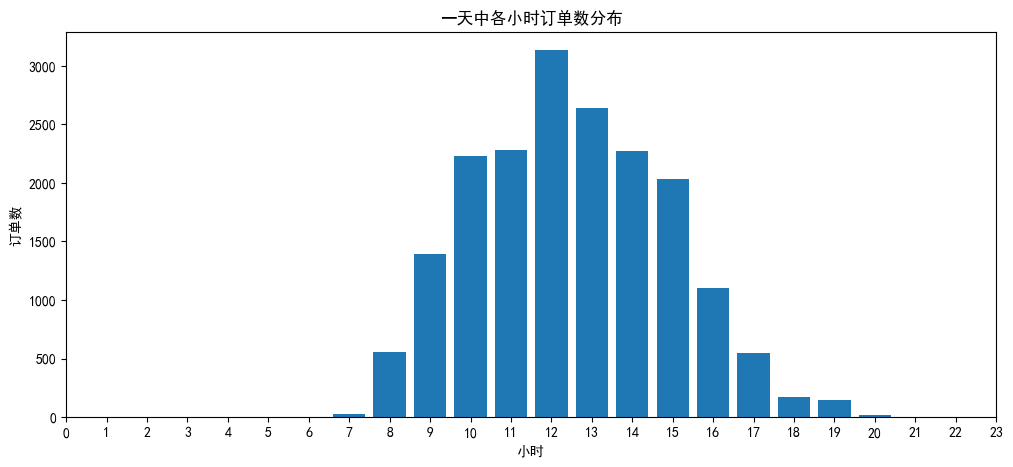

In [62]:
plt.figure(figsize=(12, 5))
plt.bar(hour_summary["Hour"], hour_summary["order_count"])
plt.xlabel("小时")
plt.ylabel("订单数")
plt.title("一天中各小时订单数分布")
plt.xticks(range(0, 24))
plt.show()

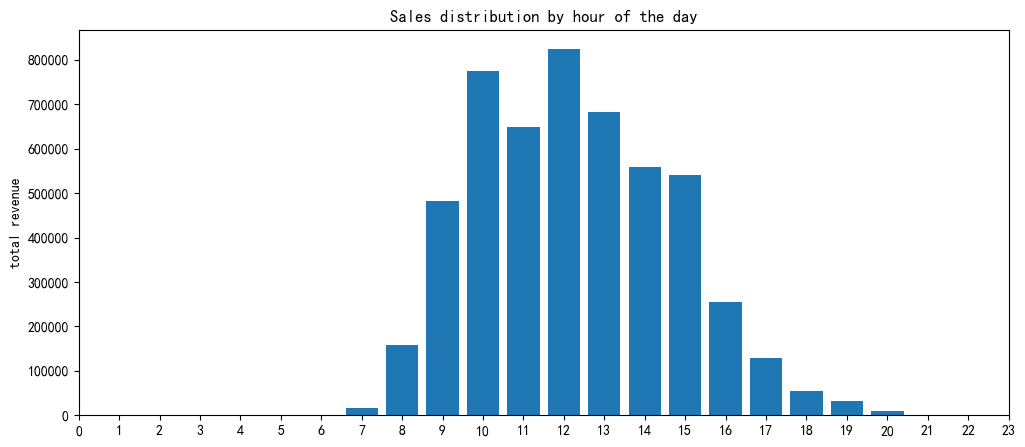

In [63]:
plt.figure(figsize=(12, 5))
plt.bar(hour_summary["Hour"], hour_summary["quantity_sum"])
plt.xlabel("")
plt.ylabel("total revenue")
plt.title("Sales distribution by hour of the day")
plt.xticks(range(0, 24))
plt.show()

In [64]:
peak_order_hour = hour_summary.loc[hour_summary["order_count"].idxmax(), "Hour"]
peak_revenue_hour = hour_summary.loc[hour_summary["revenue_sum"].idxmax(), "Hour"]

print(f"The hour with the highest number of orders：{peak_order_hour} 点")
print(f"The hour with the highest number of revenue：{peak_revenue_hour} 点")

The hour with the highest number of orders：12 点
The hour with the highest number of revenue：12 点


## weekend or weekdays

In [65]:
df_clean["WeekendType"] = df_clean["IsWeekend"].map({0: "weekdays", 1: "weekends"})

In [66]:
weekend_summary = (
    df_clean.groupby("WeekendType")
    .agg(
        order_count=("InvoiceNo", "nunique"),
        quantity_sum=("Quantity", "sum"),
        revenue_sum=("Revenue", "sum")
    )
    .reset_index()
)

weekend_summary["avg_order_value"] = weekend_summary["revenue_sum"] / weekend_summary["order_count"]

weekend_summary

,WeekendType,order_count,quantity_sum,revenue_sum,avg_order_value
0,weekdays,16363,4701340,8118893.683,496.173910
1,weekends,2169,466472,792514.221,365.382306


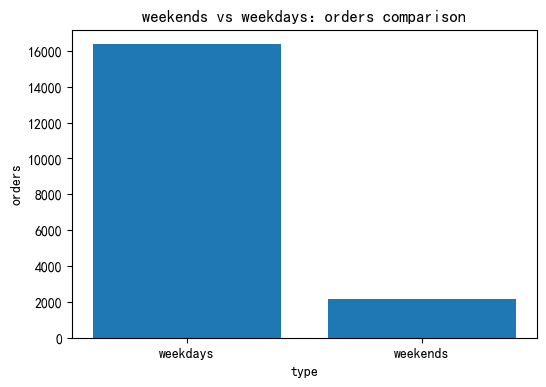

In [67]:
plt.figure(figsize=(6, 4))
plt.bar(weekend_summary["WeekendType"], weekend_summary["order_count"])
plt.xlabel("type")
plt.ylabel("orders")
plt.title("weekends vs weekdays：orders comparison")
plt.show()

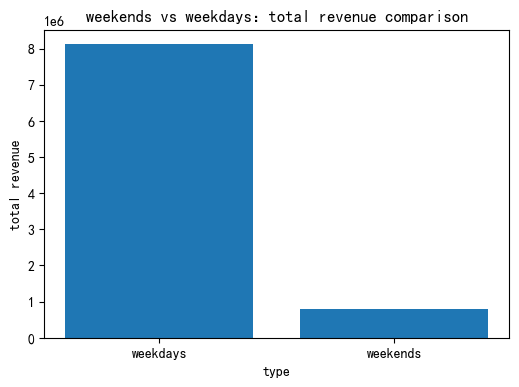

In [68]:
plt.figure(figsize=(6, 4))
plt.bar(weekend_summary["WeekendType"], weekend_summary["revenue_sum"])
plt.xlabel("type")
plt.ylabel("total revenue")
plt.title("weekends vs weekdays：total revenue comparison")
plt.show()

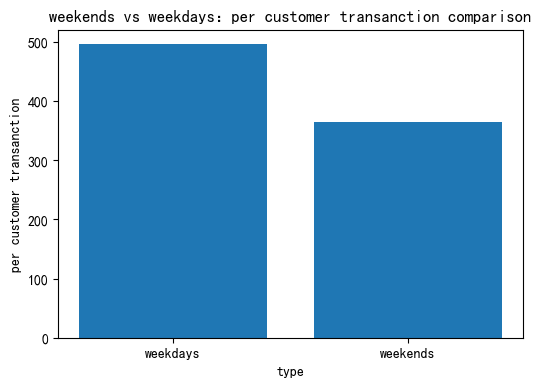

In [69]:
plt.figure(figsize=(6, 4))
plt.bar(weekend_summary["WeekendType"], weekend_summary["avg_order_value"])
plt.xlabel("type")
plt.ylabel("per customer transanction")
plt.title("weekends vs weekdays：per customer transanction comparison")
plt.show()

## Which day of the week is the most active: DayOfWeek analysis

In [70]:
day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df_clean["DayName"] = df_clean["DayOfWeek"].map(day_map)

In [71]:
dow_summary = (
    df_clean.groupby(["DayOfWeek", "DayName"])
    .agg(
        order_count=("InvoiceNo", "nunique"),
        quantity_sum=("Quantity", "sum"),
        revenue_sum=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("DayOfWeek")
)

dow_summary["avg_order_value"] = dow_summary["revenue_sum"] / dow_summary["order_count"]

dow_summary

,DayOfWeek,DayName,order_count,quantity_sum,revenue_sum,avg_order_value
0,0,Monday,2863,769001,1367146.411,477.522323
1,1,Tuesday,3184,1007859,1700634.631,534.118917
2,2,Wednesday,3455,962417,1588336.170,459.721033
3,3,Thursday,4032,1151845,1976859.070,490.292428
4,4,Friday,2829,810218,1485917.401,525.244751
5,6,Sunday,2169,466472,792514.221,365.382306


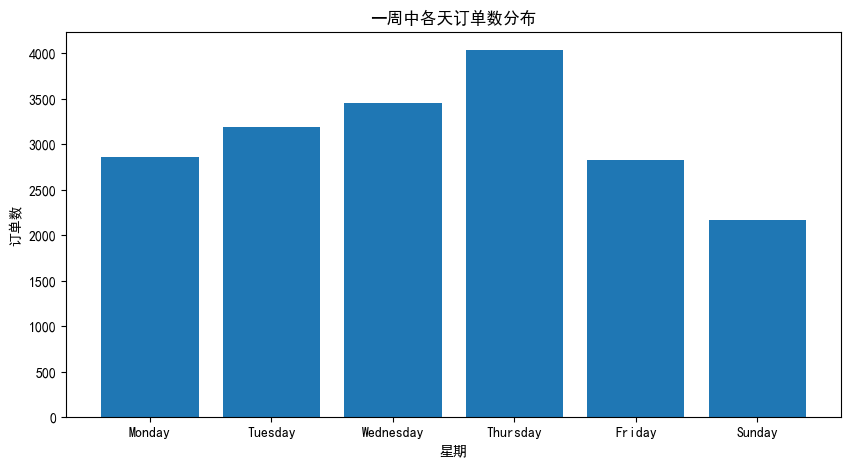

In [72]:
plt.figure(figsize=(10, 5))
plt.bar(dow_summary["DayName"], dow_summary["order_count"])
plt.xlabel("星期")
plt.ylabel("订单数")
plt.title("一周中各天订单数分布")
plt.show()

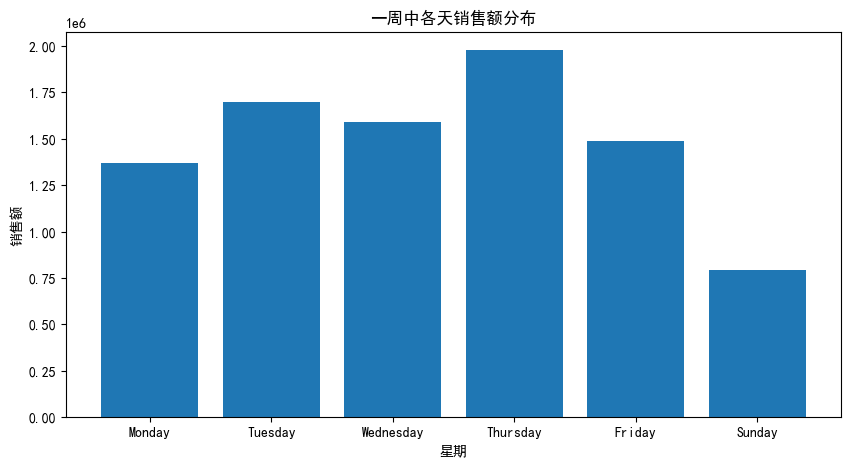

In [73]:
plt.figure(figsize=(10, 5))
plt.bar(dow_summary["DayName"], dow_summary["revenue_sum"])
plt.xlabel("星期")
plt.ylabel("销售额")
plt.title("一周中各天销售额分布")
plt.show()

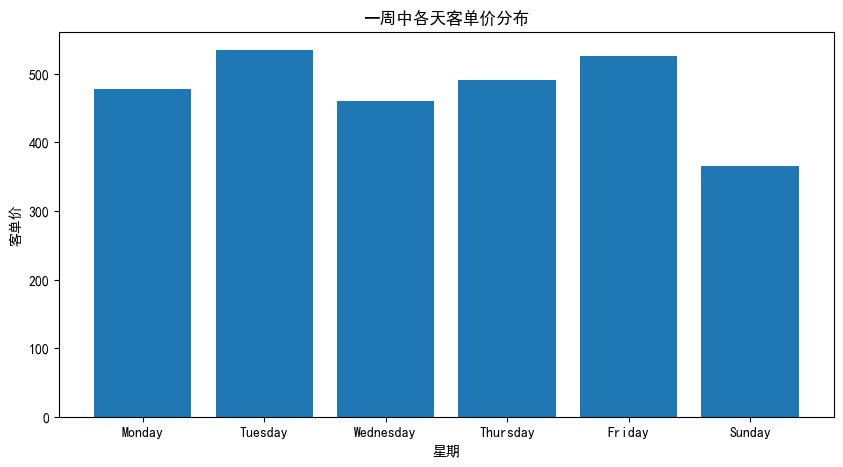

In [74]:
plt.figure(figsize=(10, 5))
plt.bar(dow_summary["DayName"], dow_summary["avg_order_value"])
plt.xlabel("星期")
plt.ylabel("客单价")
plt.title("一周中各天客单价分布")
plt.show()